In [18]:
"""
[고령화 파트] 노인 인프라 수급 균형(의료 vs 복지) 및 10년간 증감률(CAGR) 분석

사용 데이터
- senior_welfare_facilities_raw.csv
- kosis_care_hospitals_yearly.csv

1. 데이터 결측치 검증 및 전처리
2. 2024년 기준 지역별 '전문 의료(요양병원)' vs '지역사회 복지(노인복지시설)' 상대적 수급 균형(Min-Max 정규화) 산출
3. 2015~2024년(10년간) 초고령화 진행에 따른 인프라별 연평균 증감률(CAGR) 비교 분석
4. 분석 결과 DataFrame 생성 및 raw 디렉토리 내 신규 CSV 파일 보관
   - senior_infra_balance_2024_analyzed.csv
   - senior_infra_cagr_2015_2024_analyzed.csv

Streamlit 앱(app/streamlit_app.py) 및 데이터 시각화 모듈에서도 동일 분석 데이터를 재사용한다.

실행: python -m src.analysis.senior_infra_balance
"""

import os
import numpy as np
import pandas as pd

# 1. 파일 경로 지정 및 데이터 불러오기
DIR_PATH = r"C:\rookies6\medical-infrastructure-viz\data\aging\raw"
welfare_path = os.path.join(DIR_PATH, "senior_welfare_facilities_raw.csv")
hospital_path = os.path.join(DIR_PATH, "kosis_care_hospitals_raw.csv")

df_welfare = pd.read_csv(welfare_path)
df_hospital = pd.read_csv(hospital_path)

print("=== 1. 결측치 확인 및 전처리 ===")
print("[복지시설 데이터 결측치 수]")
print(df_welfare.isnull().sum().sum())
print("[요양병원 데이터 결측치 수]")
print(df_hospital.isnull().sum().sum())

# 2. 지역명 통일 함수 (시도 매핑)
region_map = {
    "서울": "서울특별시",
    "부산": "부산광역시",
    "대구": "대구광역시",
    "인천": "인천광역시",
    "광주": "광주광역시",
    "대전": "대전광역시",
    "울산": "울산광역시",
    "세종": "세종특별자치시",
    "경기": "경기도",
    "강원": "강원특별자치도",
    "충북": "충청북도",
    "충남": "충청남도",
    "전북": "전북특별자치도",
    "전남": "전라남도",
    "경북": "경상북도",
    "경남": "경상남도",
    "제주": "제주특별자치도",
}


def clean_region(name):
    for short, full in region_map.items():
        if short in str(name):
            return full
    return name

=== 1. 결측치 확인 및 전처리 ===
[복지시설 데이터 결측치 수]
0
[요양병원 데이터 결측치 수]
0


In [19]:
# ---------------------------------------------------------
# [분석 1] 2024년 지역별 노인 인프라 상대적 수급 균형 (Min-Max 정규화)
# ---------------------------------------------------------
# A. 복지시설 2024년 시설 합계 구하기
df_wel_2024 = df_welfare[df_welfare["연도"] == 2024].copy()

# 대표 복지시설 컬럼 산출 (경로당 + 복지관 + 주요 재가/지원은 시설수 컬럼 합산)
wel_facility_cols = [c for c in df_wel_2024.columns if "시설수" in c] + [
    "노인여가복지시설_경로당",
    "노인여가복지시설_복지관",
]
df_wel_2024["복지시설_합계"] = df_wel_2024[wel_facility_cols].sum(axis=1)
df_wel_2024["시도_clean"] = df_wel_2024["시도"].apply(clean_region)
df_wel_2024_sub = df_wel_2024[["시도_clean", "복지시설_합계"]]

# B. 요양병원 2024년 개수 추출
df_hosp_2024 = df_hospital[["시도별(1)", "2024_의료기관_요양병원"]].copy()
df_hosp_2024.columns = ["시도", "요양병원_수"]
df_hosp_2024 = df_hosp_2024[df_hosp_2024["시도"] != "계"]
df_hosp_2024["시도_clean"] = df_hosp_2024["시도"].apply(clean_region)
df_hosp_2024_sub = df_hosp_2024[["시도_clean", "요양병원_수"]]

# C. 병합 및 Min-Max 정규화 (0~1)
df_balance = pd.merge(df_wel_2024_sub, df_hosp_2024_sub, on="시도_clean")


def min_max(series):
    return (series - series.min()) / (series.max() - series.min())


df_balance["복지시설_정규화"] = min_max(df_balance["복지시설_합계"])
df_balance["요양병원_정규화"] = min_max(df_balance["요양병원_수"])

# 상대적 치우침 지수 (복지시설 점수 - 요양병원 점수)
# +값: 복지/돌봄 상대적 우위, -값: 전문 의료(요양병원) 상대적 우위
df_balance["인프라_치우침_지수"] = (
    df_balance["복지시설_정규화"] - df_balance["요양병원_정규화"]
)
df_balance["성향_분류"] = df_balance["인프라_치우침_지수"].apply(
    lambda x: "복지/돌봄 중심"
    if x > 0.05
    else ("전문 의료(요양병원) 중심" if x < -0.05 else "균형")
)

In [20]:
# ---------------------------------------------------------
# [분석 2] 2015~2024년 인프라 연평균 증감률 (CAGR) 비교
# ---------------------------------------------------------
# A. 복지시설 2015 vs 2024
df_wel_2015 = df_welfare[df_welfare["연도"] == 2015].copy()
df_wel_2015["복지시설_합계_2015"] = df_wel_2015[wel_facility_cols].sum(axis=1)
df_wel_2015["시도_clean"] = df_wel_2015["시도"].apply(clean_region)

df_cagr_wel = pd.merge(
    df_wel_2015[["시도_clean", "복지시설_합계_2015"]],
    df_wel_2024[["시도_clean", "복지시설_합계"]].rename(
        columns={"복지시설_합계": "복지시설_합계_2024"}
    ),
    on="시도_clean",
)

# CAGR 공식: (2024년 / 2015년)^(1/9) - 1
df_cagr_wel["복지시설_CAGR(%)"] = (
    (
        (df_cagr_wel["복지시설_합계_2024"] / df_cagr_wel["복지시설_합계_2015"])
        ** (1 / 9)
    )
    - 1
) * 100

# B. 요양병원 2015 vs 2024
df_hosp_cagr = df_hospital[df_hospital["시도별(1)"] != "계"].copy()
df_hosp_cagr["시도_clean"] = df_hosp_cagr["시도별(1)"].apply(clean_region)
df_hosp_cagr["요양병원_CAGR(%)"] = (
    (
        (
            df_hosp_cagr["2024_의료기관_요양병원"]
            / df_hosp_cagr["2015_의료기관_요양병원"]
        )
        ** (1 / 9)
    )
    - 1
) * 100

# C. CAGR 통합 결과표 생성
df_cagr_merged = pd.merge(
    df_cagr_wel[["시도_clean", "복지시설_합계_2015", "복지시설_합계_2024", "복지시설_CAGR(%)"]],
    df_hosp_cagr[
        [
            "시도_clean",
            "2015_의료기관_요양병원",
            "2024_의료기관_요양병원",
            "요양병원_CAGR(%)",
        ]
    ].rename(
        columns={
            "2015_의료기관_요양병원": "요양병원_수_2015",
            "2024_의료기관_요양병원": "요양병원_수_2024",
        }
    ),
    on="시도_clean",
)

df_cagr_merged["10년간_변화_경향"] = df_cagr_merged.apply(
    lambda r: "의료 인프라 중심 성장"
    if r["요양병원_CAGR(%)"] > r["복지시설_CAGR(%)"]
    else "복지/돌봄 인프라 중심 성장",
    axis=1,
)

In [21]:
# ---------------------------------------------------------
# [3] 저장 경로 설정 및 디렉터리 생성
# ---------------------------------------------------------
# 결과물이 저장될 폴더 경로 지정
RESULT_DIR = r"C:\rookies6\medical-infrastructure-viz\data\aging\result"

# 폴더가 존재하지 않는 경우 자동으로 생성 (exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

# 파일 저장 전체 경로 설정
balance_save_path = os.path.join(
    RESULT_DIR, "senior_infra_balance_2024_analyzed.csv"
)
cagr_save_path = os.path.join(
    RESULT_DIR, "senior_infra_cagr_2015_2024_analyzed.csv"
)

df_balance.to_csv(balance_save_path, index=False, encoding="utf-8-sig")
df_cagr_merged.to_csv(cagr_save_path, index=False, encoding="utf-8-sig")

print("\n=== 2. 데이터 처리 및 보관 완료 ===")
print(f"- 수급 균형 분석 파일 저장 완료: {balance_save_path}")
print(f"- CAGR 분석 파일 저장 완료: {cagr_save_path}")

# 결과 출력 확인
print("\n[2024년 인프라 수급 균형 결과 예시 (상위 5개)]")
display(df_balance.head())

print("\n[2015~2024 연평균 증감률(CAGR) 결과 예시 (상위 5개)]")
display(df_cagr_merged.head())


=== 2. 데이터 처리 및 보관 완료 ===
- 수급 균형 분석 파일 저장 완료: C:\rookies6\medical-infrastructure-viz\data\aging\result\senior_infra_balance_2024_analyzed.csv
- CAGR 분석 파일 저장 완료: C:\rookies6\medical-infrastructure-viz\data\aging\result\senior_infra_cagr_2015_2024_analyzed.csv

[2024년 인프라 수급 균형 결과 예시 (상위 5개)]


,시도_clean,복지시설_합계,요양병원_수,복지시설_정규화,요양병원_정규화,인프라_치우침_지수,성향_분류
0,서울특별시,6167,107,0.399128,0.368794,0.030333,균형
1,부산광역시,3424,160,0.202961,0.556738,-0.353777,전문 의료(요양병원) 중심
2,대구광역시,2631,71,0.146249,0.241135,-0.094886,전문 의료(요양병원) 중심
3,인천광역시,2767,62,0.155975,0.209220,-0.053245,전문 의료(요양병원) 중심
4,광주광역시,2127,60,0.110205,0.202128,-0.091922,전문 의료(요양병원) 중심



[2015~2024 연평균 증감률(CAGR) 결과 예시 (상위 5개)]


,시도_clean,복지시설_합계_2015,복지시설_합계_2024,복지시설_CAGR(%),요양병원_수_2015,요양병원_수_2024,요양병원_CAGR(%),10년간_변화_경향
0,서울특별시,3948,6167,5.080436,103,107,0.424229,복지/돌봄 인프라 중심 성장
1,부산광역시,2441,3424,3.831602,190,160,-1.891333,복지/돌봄 인프라 중심 성장
2,대구광역시,1609,2631,5.615929,61,71,1.701039,복지/돌봄 인프라 중심 성장
3,인천광역시,1598,2767,6.290020,64,62,-0.352142,복지/돌봄 인프라 중심 성장
4,광주광역시,1561,2127,3.497390,49,60,2.275779,복지/돌봄 인프라 중심 성장


In [23]:
import json
import os
import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

# ---------------------------------------------------------
# 0. 한글 폰트 및 마이너스 깨짐 방지 설정
# ---------------------------------------------------------
plt.rcParams["font.family"] = "Malgun Gothic"  # Windows: Malgun Gothic, Mac: AppleGothic
plt.rcParams["axes.unicode_minus"] = False

# 분석된 CSV 데이터 불러오기
RESULT_PATH = r"C:\rookies6\medical-infrastructure-viz\data\aging\result"
df_balance = pd.read_csv(
    os.path.join(RESULT_PATH, "senior_infra_balance_2024_analyzed.csv")
)
df_cagr = pd.read_csv(
    os.path.join(RESULT_PATH, "senior_infra_cagr_2015_2024_analyzed.csv")
)


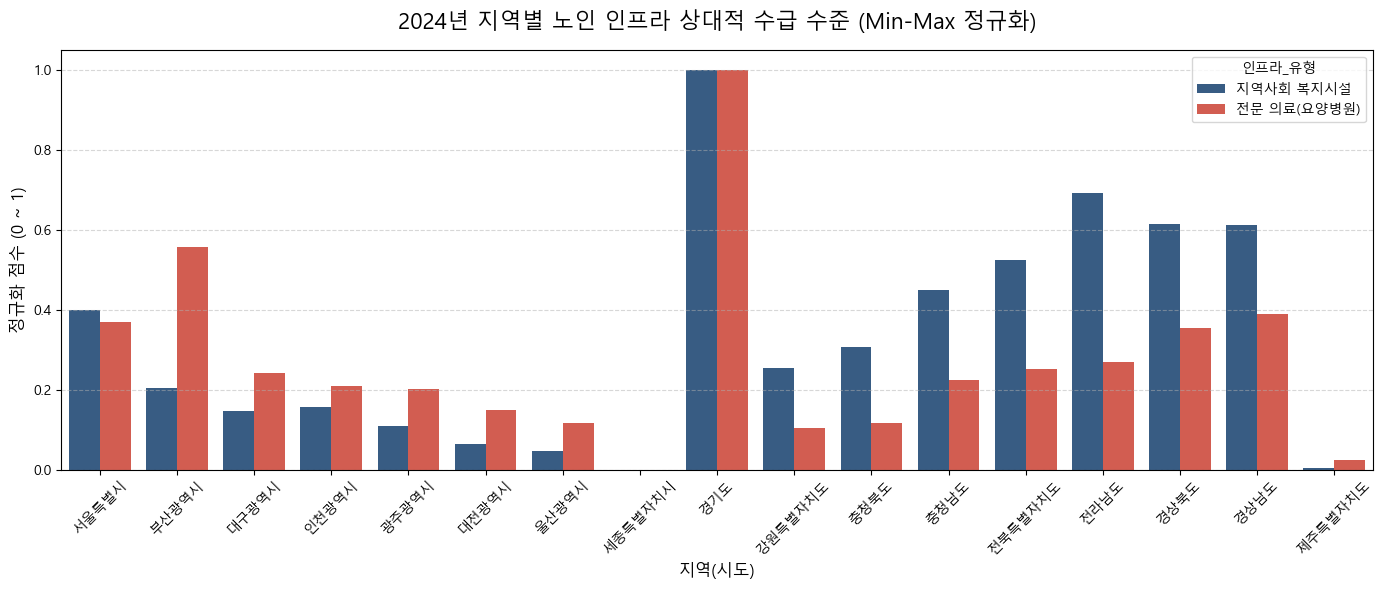

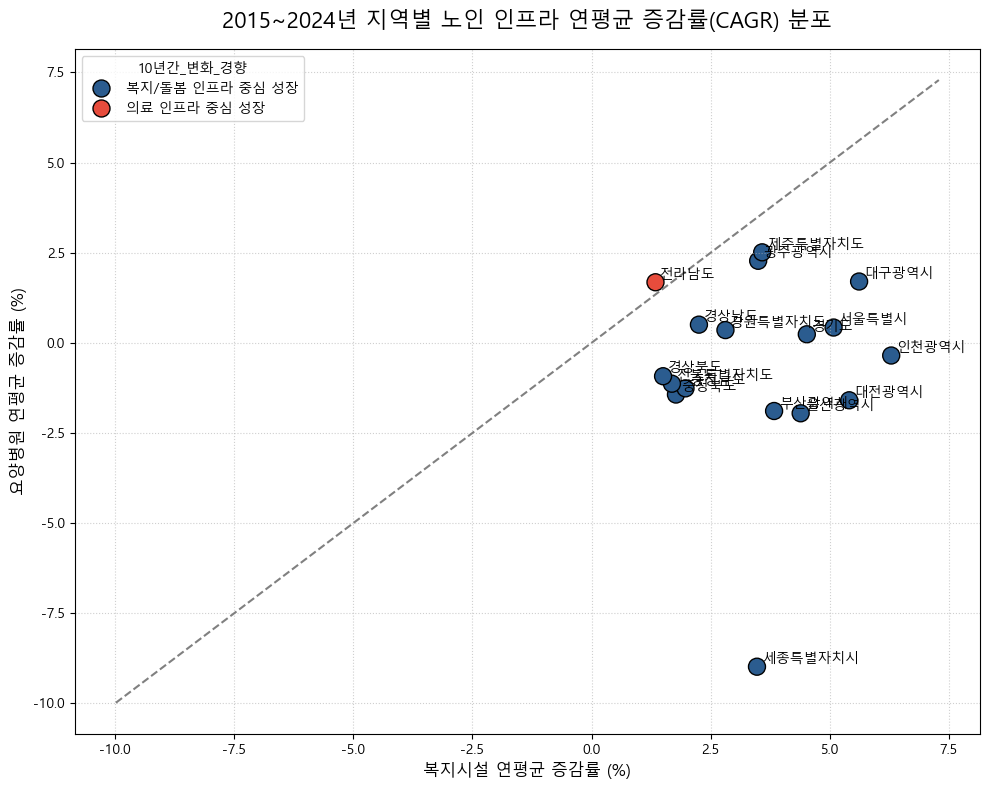

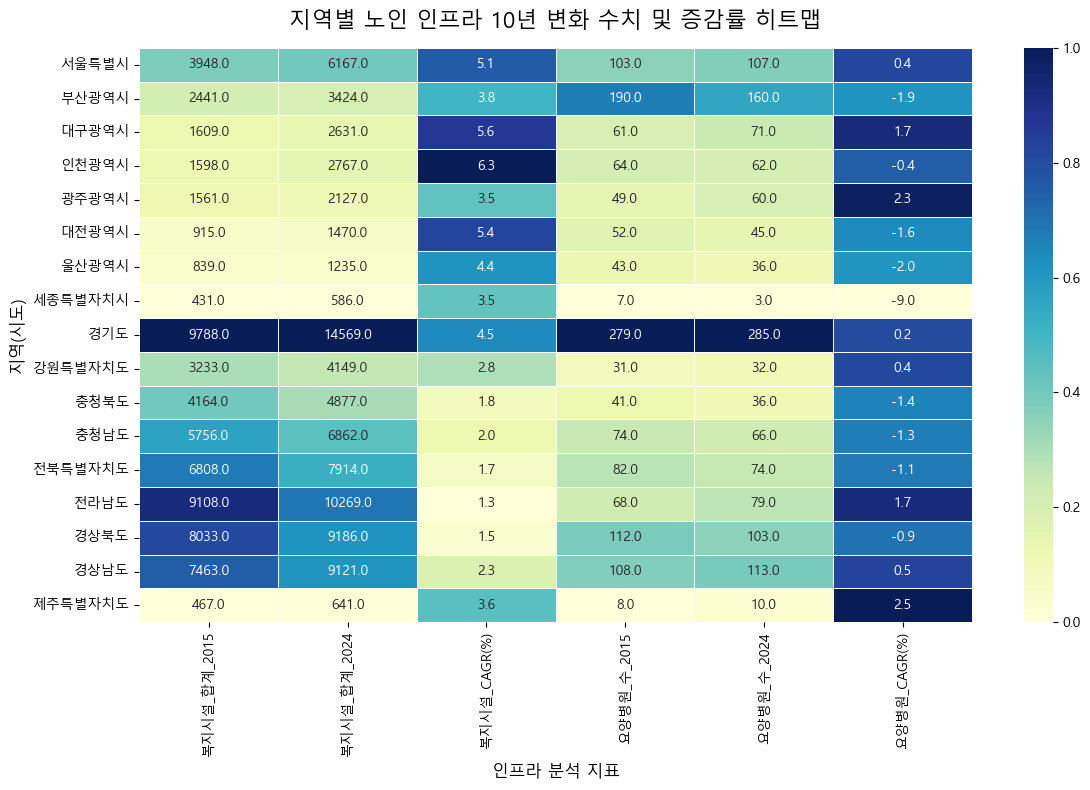

In [26]:


# ---------------------------------------------------------
# 1. Bar Plot : 지역별 노인복지시설 vs 요양병원 상대수준 비교
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))

df_melted = df_balance.melt(
    id_vars=["시도_clean"],
    value_vars=["복지시설_정규화", "요양병원_정규화"],
    var_name="인프라_유형",
    value_name="정규화_점수",
)
df_melted["인프라_유형"] = df_melted["인프라_유형"].replace(
    {"복지시설_정규화": "지역사회 복지시설", "요양병원_정규화": "전문 의료(요양병원)"}
)

sns.barplot(
    data=df_melted,
    x="시도_clean",
    y="정규화_점수",
    hue="인프라_유형",
    palette=["#2b5c8f", "#e74c3c"],
    ax=ax,
)
ax.set_title(
    "2024년 지역별 노인 인프라 상대적 수급 수준 (Min-Max 정규화)",
    fontsize=16,
    pad=15,
)
ax.set_xlabel("지역(시도)", fontsize=12)
ax.set_ylabel("정규화 점수 (0 ~ 1)", fontsize=12)
plt.xticks(rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 2. 산점도 (Scatter Plot) : 복지시설 vs 요양병원 10년간 성장률(CAGR) 비교
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    data=df_cagr,
    x="복지시설_CAGR(%)",
    y="요양병원_CAGR(%)",
    hue="10년간_변화_경향",
    palette={"의료 인프라 중심 성장": "#e74c3c", "복지/돌봄 인프라 중심 성장": "#2b5c8f"},
    s=150,
    edgecolor="black",
    ax=ax,
)

# 지역 라벨링 표시
for idx, row in df_cagr.iterrows():
    ax.text(
        row["복지시설_CAGR(%)"] + 0.1,
        row["요양병원_CAGR(%)"] + 0.1,
        row["시도_clean"],
        fontsize=10,
    )

# 기준선 (1:1 선) 추가
max_val = max(df_cagr["복지시설_CAGR(%)"].max(), df_cagr["요양병원_CAGR(%)"].max()) + 1
min_val = min(df_cagr["복지시설_CAGR(%)"].min(), df_cagr["요양병원_CAGR(%)"].min()) - 1
ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="gray",
    linestyle="--",
    label="증감률 균형선",
)

ax.set_title(
    "2015~2024년 지역별 노인 인프라 연평균 증감률(CAGR) 분포",
    fontsize=16,
    pad=15,
)
ax.set_xlabel("복지시설 연평균 증감률 (%)", fontsize=12)
ax.set_ylabel("요양병원 연평균 증감률 (%)", fontsize=12)
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. 히트맵 (Heatmap) : 주요 지역별 10년간 인프라 지표 및 CAGR 종합
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

df_heatmap_data = df_cagr.set_index("시도_clean")[
    [
        "복지시설_합계_2015",
        "복지시설_합계_2024",
        "복지시설_CAGR(%)",
        "요양병원_수_2015",
        "요양병원_수_2024",
        "요양병원_CAGR(%)",
    ]
]

# 컬럼별 스케일 차이가 크므로 열 기준 Min-Max 정규화하여 히트맵 시각화
df_heatmap_norm = (df_heatmap_data - df_heatmap_data.min()) / (
    df_heatmap_data.max() - df_heatmap_data.min()
)

sns.heatmap(
    df_heatmap_norm,
    annot=df_heatmap_data.values,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax,
)
ax.set_title(
    "지역별 노인 인프라 10년 변화 수치 및 증감률 히트맵", fontsize=16, pad=15
)
ax.set_xlabel("인프라 분석 지표", fontsize=12)
ax.set_ylabel("지역(시도)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# [1] 요약 정보 산출을 위한 기초 통계 집계
# ---------------------------------------------------------
# 1. 수급 균형 (2024년)
most_welfare = df_balance.sort_values(
    by="인프라_치우침_지수", ascending=False
).iloc[0]
most_medical = df_balance.sort_values(
    by="인프라_치우침_지수", ascending=True
).iloc[0]
mean_bias = df_balance["인프라_치우침_지수"].mean()

welfare_count = (df_balance["인프라_치우침_지수"] > 0).sum()
medical_count = (df_balance["인프라_치우침_지수"] < 0).sum()

# 2. CAGR 증감률 (2015~2024년)
mean_welfare_cagr = df_cagr_merged["복지시설_CAGR(%)"].mean()
mean_hospital_cagr = df_cagr_merged["요양병원_CAGR(%)"].mean()

top_welfare_cagr = df_cagr_merged.sort_values(
    by="복지시설_CAGR(%)", ascending=False
).iloc[0]
top_hospital_cagr = df_cagr_merged.sort_values(
    by="요양병원_CAGR(%)", ascending=False
).iloc[0]

# 3. 10년간(2015~2024) 전국 총 수량 변화
tot_welfare_2015 = df_cagr_merged["복지시설_합계_2015"].sum()
tot_welfare_2024 = df_cagr_merged["복지시설_합계_2024"].sum()
tot_welfare_diff = tot_welfare_2024 - tot_welfare_2015
tot_welfare_cagr = (
    (tot_welfare_2024 / tot_welfare_2015) ** (1 / 9) - 1
) * 100

tot_hospital_2015 = df_cagr_merged["요양병원_수_2015"].sum()
tot_hospital_2024 = df_cagr_merged["요양병원_수_2024"].sum()
tot_hospital_diff = tot_hospital_2024 - tot_hospital_2015
tot_hospital_cagr = (
    (tot_hospital_2024 / tot_hospital_2015) ** (1 / 9) - 1
) * 100

# ---------------------------------------------------------
# [2] 종합 요약 보고서 출력
# ---------------------------------------------------------
print("=" * 65)
print(" 📊 2015~2024 노인 인프라 수급 불균형 및 10년 변화 요약 보고서")
print("=" * 65)

print("\n1️⃣ [2024년 노인 인프라 수급 불균형 현황]")
print(f"  • 복지 중심 지역 (지수 > 0) : 총 {welfare_count}개 시·도")
print(f"  • 의료 중심 지역 (지수 < 0) : 총 {medical_count}개 시·도")
print(
    f"  • 최다 복지 중심 지역     : {most_welfare['시도_clean']} (치우침 지수: +{most_welfare['인프라_치우침_지수']:.4f})"
)
print(
    f"  • 최다 의료 중심 지역     : {most_medical['시도_clean']} (치우침 지수: {most_medical['인프라_치우침_지수']:.4f})"
)
print(f"  • 전국 평균 치우침 지수   : {mean_bias:+.4f}")

print("\n2️⃣ [10년간(2015~2024) 전국 총 인프라 수량 변화]")
print(
    f"  • 노인복지시설 : {tot_welfare_2015:,}개소 ➔ {tot_welfare_2024:,}개소 (증감: {tot_welfare_diff:+,}개소 / CAGR: {tot_welfare_cagr:+.2f}%)"
)
print(
    f"  • 요 양 병 원  : {tot_hospital_2015:,}개소 ➔ {tot_hospital_2024:,}개소 (증감: {tot_hospital_diff:+,}개소 / CAGR: {tot_hospital_cagr:+.2f}%)"
)

print("\n3️⃣ [지역별 연평균 증감률(CAGR) 분포 현황]")
print(f"  • 시·도별 복지시설 평균 CAGR : {mean_welfare_cagr:+.2f}%")
print(f"  • 시·도별 요양병원 평균 CAGR : {mean_hospital_cagr:+.2f}%")
print(
    f"  • 복지시설 최고 성장 지역    : {top_welfare_cagr['시도_clean']} (+{top_welfare_cagr['복지시설_CAGR(%)']:.2f}%)"
)
print(
    f"  • 요양병원 최고 성장 지역    : {top_hospital_cagr['시도_clean']} (+{top_hospital_cagr['요양병원_CAGR(%)']:.2f}%)"
)
print("=" * 65)

# ---------------------------------------------------------
# [1] 데이터 병합 및 성장 취약지수 계산
# ---------------------------------------------------------
# df_balance(2024년 현황)와 df_cagr_merged(CAGR)를 시도명 기준으로 병합
df_vulnerable = pd.merge(df_balance, df_cagr_merged, on="시도_clean")

# Min-Max 정규화 함수 정의 (0~1 스케일링)
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

# 1. 복지시설 성장 취약도 (CAGR이 낮고, 2024년 정규화점수가 낮을수록 취약)
# (1 - scaled_value)를 적용하여 값이 작을수록 점수가 높아지도록 정방향 변환
df_vulnerable["복지_cagr_inv"] = 1 - min_max_scale(df_vulnerable["복지시설_CAGR(%)"])
df_vulnerable["복지_level_inv"] = 1 - df_vulnerable["복지시설_정규화"]
df_vulnerable["복지시설_성장취약도"] = (df_vulnerable["복지_cagr_inv"] + df_vulnerable["복지_level_inv"]) / 2

# 2. 요양병원 성장 취약도 (CAGR이 낮고, 2024년 정규화점수가 낮을수록 취약)
df_vulnerable["병원_cagr_inv"] = 1 - min_max_scale(df_vulnerable["요양병원_CAGR(%)"])
df_vulnerable["병원_level_inv"] = 1 - df_vulnerable["요양병원_정규화"]
df_vulnerable["요양병원_성장취약도"] = (df_vulnerable["병원_cagr_inv"] + df_vulnerable["병원_level_inv"]) / 2

# 3. 종합 성장 취약지수 (두 영역 평균 후 0~100점 환산)
df_vulnerable["종합_성장취약지수"] = min_max_scale(
    (df_vulnerable["복지시설_성장취약도"] + df_vulnerable["요양병원_성장취약도"]) / 2
) * 100

# ---------------------------------------------------------
# [2] 성장 취약지 TOP 5 추출 및 출력
# ---------------------------------------------------------
top5_vulnerable = df_vulnerable.sort_values(
    by="종합_성장취약지수", ascending=False
).head(5)

print("=" * 70)
print(" 🚨 [종합 노인 인프라 성장 취약지역 TOP 5] (성장 정체 & 공급 부족 지역)")
print("=" * 70)

display_cols = [
    "시도_clean", 
    "종합_성장취약지수", 
    "복지시설_CAGR(%)", 
    "요양병원_CAGR(%)", 
    "복지시설_합계_2024", 
    "요양병원_수_2024"
]

# 깔끔한 출력을 위한 데이터프레임 정리
top5_display = top5_vulnerable[display_cols].copy()
top5_display.columns = [
    "지역(시도)", "종합 취약지수(100점)", "복지시설 CAGR(%)", "요양병원 CAGR(%)", "2024 복지시설", "2024 요양병원"
]
top5_display["종합 취약지수(100점)"] = top5_display["종합 취약지수(100점)"].round(2)
top5_display["복지시설 CAGR(%)"] = top5_display["복지시설 CAGR(%)"].round(2)
top5_display["요양병원 CAGR(%)"] = top5_display["요양병원 CAGR(%)"].round(2)

display(top5_display)

# ---------------------------------------------------------
# [3] 취약지 선정 결과 파일 저장 (data/aging/result)
# ---------------------------------------------------------
RESULT_DIR = r"C:\rookies6\medical-infrastructure-viz\data\aging\result"
os.makedirs(RESULT_DIR, exist_ok=True)

vulnerable_save_path = os.path.join(RESULT_DIR, "senior_infra_vulnerable_top5.csv")
top5_display.to_csv(vulnerable_save_path, index=False, encoding="utf-8-sig")

print(f"\n✅ 성장 취약지 분석 결과 저장 완료: {vulnerable_save_path}")

 📊 2015~2024 노인 인프라 수급 불균형 및 10년 변화 요약 보고서

1️⃣ [2024년 노인 인프라 수급 불균형 현황]
  • 복지 중심 지역 (지수 > 0) : 총 8개 시·도
  • 의료 중심 지역 (지수 < 0) : 총 7개 시·도
  • 최다 복지 중심 지역     : 전라남도 (치우침 지수: +0.4230)
  • 최다 의료 중심 지역     : 부산광역시 (치우침 지수: -0.3538)
  • 전국 평균 치우침 지수   : +0.0590

2️⃣ [10년간(2015~2024) 전국 총 인프라 수량 변화]
  • 노인복지시설 : 68,162개소 ➔ 87,995개소 (증감: +19,833개소 / CAGR: +2.88%)
  • 요 양 병 원  : 1,372개소 ➔ 1,342개소 (증감: -30개소 / CAGR: -0.25%)

3️⃣ [지역별 연평균 증감률(CAGR) 분포 현황]
  • 시·도별 복지시설 평균 CAGR : +3.47%
  • 시·도별 요양병원 평균 CAGR : -0.58%
  • 복지시설 최고 성장 지역    : 인천광역시 (+6.29%)
  • 요양병원 최고 성장 지역    : 제주특별자치도 (+2.51%)
 🚨 [종합 노인 인프라 성장 취약지역 TOP 5] (성장 정체 & 공급 부족 지역)


,지역(시도),종합 취약지수(100점),복지시설 CAGR(%),요양병원 CAGR(%),2024 복지시설,2024 요양병원
7,세종특별자치시,100.00,3.47,-8.98,586,3
10,충청북도,75.54,1.77,-1.43,4877,36
6,울산광역시,68.13,4.39,-1.95,1235,36
9,강원특별자치도,65.61,2.81,0.35,4149,32
11,충청남도,65.47,1.97,-1.26,6862,66



✅ 성장 취약지 분석 결과 저장 완료: C:\rookies6\medical-infrastructure-viz\data\aging\result\senior_infra_vulnerable_top5.csv
